In [47]:
# source: src/utils/fakeprints.py
import torch
import librosa
import numpy as np


def load_audio(file_path, max_duration=None):
    try:
        waveform, sr = librosa.load(file_path, sr=None, mono=True, duration=max_duration)
        waveform = torch.from_numpy(waveform).unsqueeze(0)  # (1, num_samples)
        return waveform, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


def get_spectrum(transform, waveform):
    with torch.no_grad():
        spec = transform(waveform) # (B, 1, L) -> (B, n_bins, T')

    spec = 10 * torch.log10(torch.clamp(spec, min=1e-10, max=1e6))
    return spec


def get_freqs(n_fft, sr, log=True, bins_per_octave=192, fmin=32.7):
    if log:
        nyquist = sr / 2
        n_octaves = np.log2(nyquist / fmin)
        nbins = int(n_octaves * bins_per_octave)
        bin_indices = torch.arange(nbins + 1)
        freqs = fmin * (2 ** (bin_indices / bins_per_octave))
    else:
        freqs = torch.linspace(0, sr / 2, steps=n_fft // 2 + 1)
    return freqs


def get_freqs_mask(freqs, sr, freq_range):
    actual_fmax = min(freq_range[1], sr // 2)
    mask = (freqs >= freq_range[0]) & (freqs <= actual_fmax)
    return mask


def get_low_hull_curve(x, area=20):
    """
    For each sample, compute the lower hull envelope evaluated at every bin.
    x: (B, n_bins)
    Returns: (B, n_bins) lower hull curve
    """
    B, n = x.shape

    # Find anchor indices per sample
    windows = x.unfold(1, area, 1)   # (B, num_windows, area)
    rel_idx = windows.argmin(dim=2)  # (B, num_windows)
    offsets = torch.arange(rel_idx.shape[1], device=x.device)
    abs_idx = rel_idx + offsets      # (B, num_windows)

    # Mark selected bins per sample, always include endpoints
    anchor_mask = torch.zeros(B, n, dtype=torch.bool, device=x.device)
    anchor_mask.scatter_(1, abs_idx, True)
    anchor_mask[:, 0] = True
    anchor_mask[:, n - 1] = True  # (B, n_bins) bool

    # Interpolate hull at every bin position
    # For each bin j, find the nearest anchor to the left and right *per sample*
    # We encode anchor positions as their index, non-anchors as 0/inf, then
    # do a forward/backward cummax to propagate neighbour indices.

    bin_pos = torch.arange(n, device=x.device).unsqueeze(0).expand(B, -1)  # (B, n)

    # Left anchor index: propagate forward
    left_idx = torch.where(anchor_mask, bin_pos, torch.zeros_like(bin_pos))
    left_idx, _ = left_idx.cummax(dim=1)

    # Right anchor index: propagate backward
    right_idx = torch.where(anchor_mask, bin_pos, torch.full_like(bin_pos, n - 1))
    right_idx = torch.flip(
        torch.flip(right_idx, dims=[1]).cummin(dim=1)[0], dims=[1]
    )                                       

    # Gather y-values at left/right anchors
    y_left  = x.gather(1, left_idx)   # (B, n)
    y_right = x.gather(1, right_idx)  # (B, n)

    # Linear interpolation weight
    span = (right_idx - left_idx).float().clamp_min(1)
    weight = (bin_pos - left_idx).float() / span       # (B, n)

    hull_curve = y_left + weight * (y_right - y_left)  # (B, n)
    return hull_curve

In [48]:
import torch
import torch.nn as nn
from nnAudio.Spectrogram import STFT

class Cepstrum(nn.Module):
    def __init__(
        self,
        n_fft=2048,
        sr=44100,
        hop_length=512,
        fmin=32.7,
    ):
        super().__init__()
        self.n_fft = n_fft
        self.sr = sr
        self.hop_length = hop_length
        self.fmin = fmin
        
        # 1. Initialize nnAudio STFT Layer
        # We want the Magnitude (abs(Z)), not complex numbers.
        self.stft = STFT(
            n_fft=n_fft,
            sr=sr,
            hop_length=hop_length,
            fmin=fmin,
            fmax=sr / 2,
            output_format="Magnitude",
            verbose=False,
        )

    def forward(self, waveform):
        # Input: (batch, samples)
        
        # 2. Compute STFT (Spectrogram)
        # Output shape: (batch, freq_bins, time_frames)
        # freq_bins is usually n_fft // 2 + 1
        spectrogram = self.stft(waveform)
        
        # 3. Compute Log-Magnitude
        # Add epsilon to prevent log(0)
        log_spectrogram = torch.log(spectrogram + 1e-8)
        
        # 4. Compute Inverse FFT (The "Cepstrum" step)
        # We use irfft (Inverse Real FFT) because our input is real (log-magnitude).
        # We apply this along the Frequency dimension (dim=1).
        # We specify n=n_fft so it expands back to the full quefrency range.
        cepstrum = torch.fft.irfft(log_spectrogram, n=self.n_fft, dim=1)
        cepstrum = cepstrum[:, :self.n_fft // 2 + 1, :]  # Keep only the non-negative quefrencies

        return cepstrum

In [49]:
import torch
import matplotlib.pyplot as plt

from nnAudio.features import STFT, CQT

DEVICE = torch.device("cpu")

N_FFT = 1 << 14
SR = 44100
BINS_PER_OCTAVE = 192
AREA = 20
FREQ_RANGE = [0, 25000]
FMIN = 32.7

hop_length = N_FFT // 2
fmax = SR / 2  # Maximum frequency that can be represented

freqs = get_freqs(n_fft=N_FFT, sr=SR, log=False, bins_per_octave=BINS_PER_OCTAVE, fmin=FMIN)
mask = get_freqs_mask(freqs, sr=SR, freq_range=FREQ_RANGE)
freqs = freqs.to(DEVICE)
freqs_crop = freqs[mask]
print(len(freqs))

log_freqs = get_freqs(n_fft=N_FFT, sr=SR, log=True, bins_per_octave=BINS_PER_OCTAVE, fmin=FMIN)
log_mask = get_freqs_mask(log_freqs, sr=SR, freq_range=FREQ_RANGE)
log_freqs = log_freqs.to(DEVICE)
log_freqs_crop = log_freqs[log_mask]
print(len(log_freqs))

stft_transform = STFT(
    n_fft=N_FFT,
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
    fmax=fmax,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)

cqt_transform = CQT(
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
    fmax=fmax,
    bins_per_octave=BINS_PER_OCTAVE,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)


cep_transform = Cepstrum(
    n_fft=N_FFT,
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
).to(DEVICE)

8193
1805


/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/nnAudio/utils.py:429: SyntaxWarning: If fmax is given, n_bins will be ignored
  warnings.warn("If fmax is given, n_bins will be ignored", SyntaxWarning)


Resampling /Users/emiledugelay/datasets/sunov5/394c6b8f2327462b876ac0f2272113abe32c67f70639503d3c308651211718bd.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/e4868aa013842b47045017d19e0a8bac2fd852d9940226986d9c135f43e0658f.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/d03c3d074381586ece90f51fd62e2485dfcb72711ba59e11510043e5d3e5daa4.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/a28aff7f1b4c451648e1d6930e93a57df30445f1abc79b910b5f32128b4e4836.mp3 from 48000 Hz to 44100 Hz
torch.Size([4, 8193, 323]) torch.Size([4, 1805, 323]) torch.Size([4, 8193, 323])


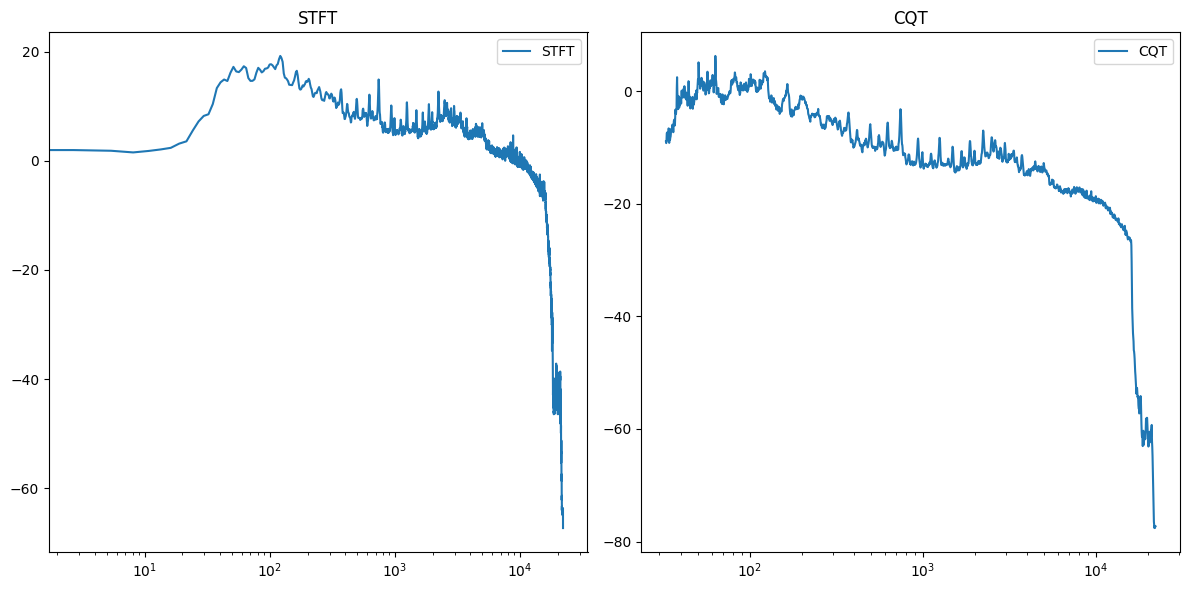

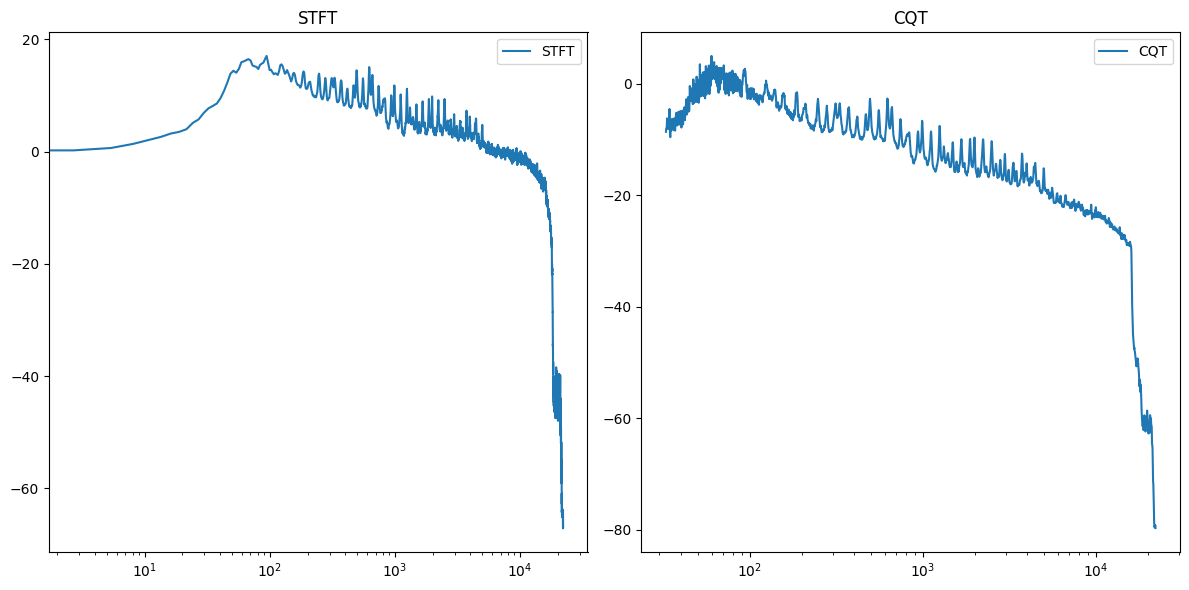

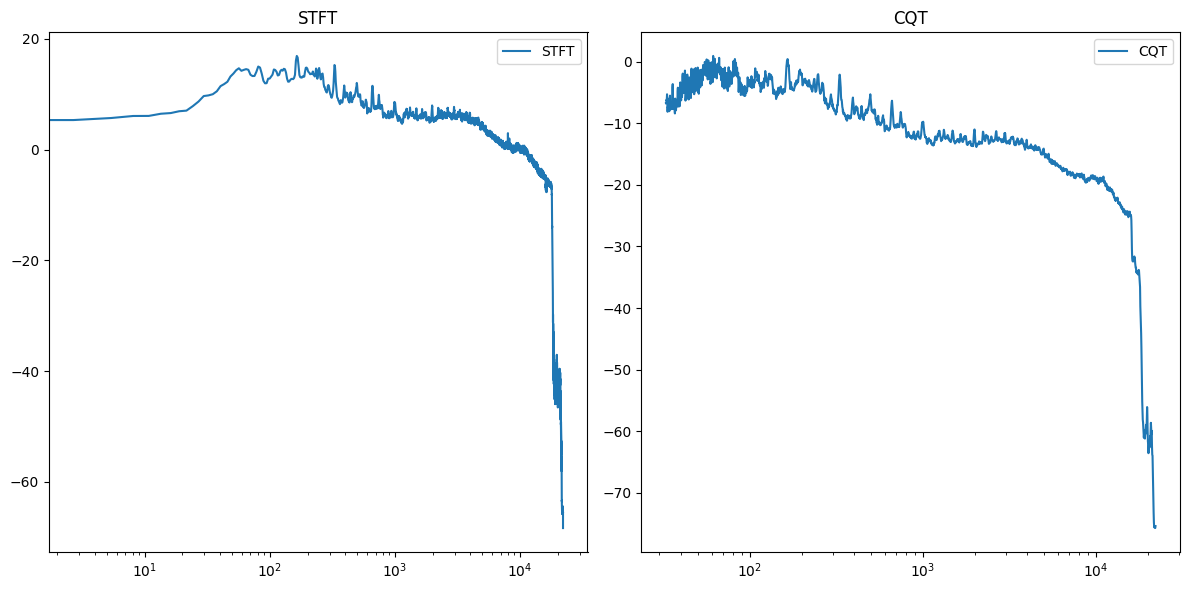

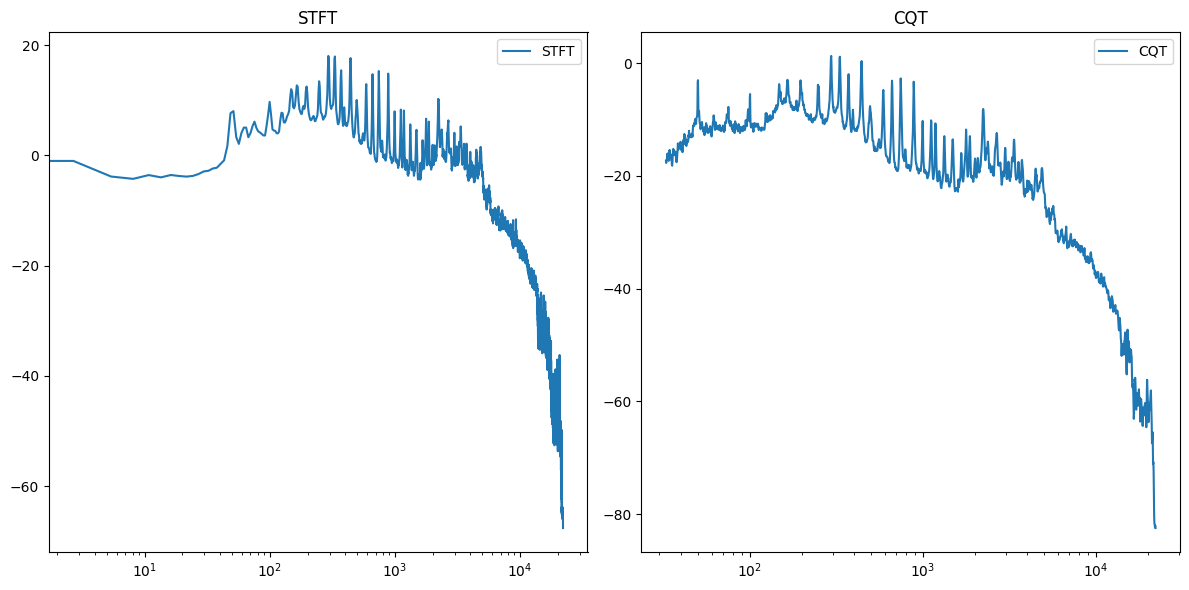

In [50]:
import glob
import soxr

MAX_DURATION = 60.0

data_dir = "/Users/emiledugelay/datasets/sunov5/"
file_paths = glob.glob(f"{data_dir}/**/*.mp3", recursive=True)
audio_paths = file_paths[:4]

waveforms = []
for path in audio_paths:
    waveform, sr = load_audio(path, max_duration=MAX_DURATION)
    if sr != SR:
        print(f"Resampling {path} from {sr} Hz to {SR} Hz")
        waveform = soxr.resample(waveform.T, sr, SR, quality="VHQ").T
        waveform = torch.from_numpy(waveform)
    waveform = waveform.mean(dim=0, keepdim=True)
    waveforms.append(waveform)

lengths = torch.tensor([w.shape[-1] for w in waveforms], device=DEVICE)
L_max = max(w.shape[-1] for w in waveforms)

padded = torch.zeros(len(waveforms), 1, L_max)
for k, w in enumerate(waveforms):
    padded[k, :, :w.shape[-1]] = w
padded = padded.to(DEVICE) # (B, 1, Lmax)

stft_batch = get_spectrum(stft_transform, padded) # (B, n_bins, T')
cqt_batch = get_spectrum(cqt_transform, padded) # (B, n_bins, T')
cep_batch = get_spectrum(cep_transform, padded) # (B, n_mfcc, T')
print(stft_batch.shape, cqt_batch.shape, cep_batch.shape)

T_frames = stft_batch.shape[-1]
frame_lengths = ((lengths - N_FFT) // hop_length + 1).unsqueeze(1) # (B, 1)
frame_mask = torch.arange(T_frames, device=DEVICE).unsqueeze(0) < frame_lengths # (B, T')

# Average over time dimension, accounting for varying lengths
stft_batch = (stft_batch * frame_mask.unsqueeze(1)).sum(-1) / frame_lengths.float() # (B, n_bins)
cqt_batch = (cqt_batch * frame_mask.unsqueeze(1)).sum(-1) / frame_lengths.float() # (B, n_bins)
cep_batch = (cep_batch * frame_mask.unsqueeze(1)).sum(-1) / frame_lengths.float() # (B, n_mfcc)


for i in range(stft_batch.shape[0]):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(freqs_crop.cpu().numpy(), stft_batch[i][mask].cpu().numpy(), label="STFT")
    plt.title("STFT")
    plt.xscale("log")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(log_freqs_crop.cpu().numpy(), cqt_batch[i][log_mask].cpu().numpy(), label="CQT")
    plt.title("CQT")
    plt.xscale("log")
    plt.legend()


    plt.tight_layout()

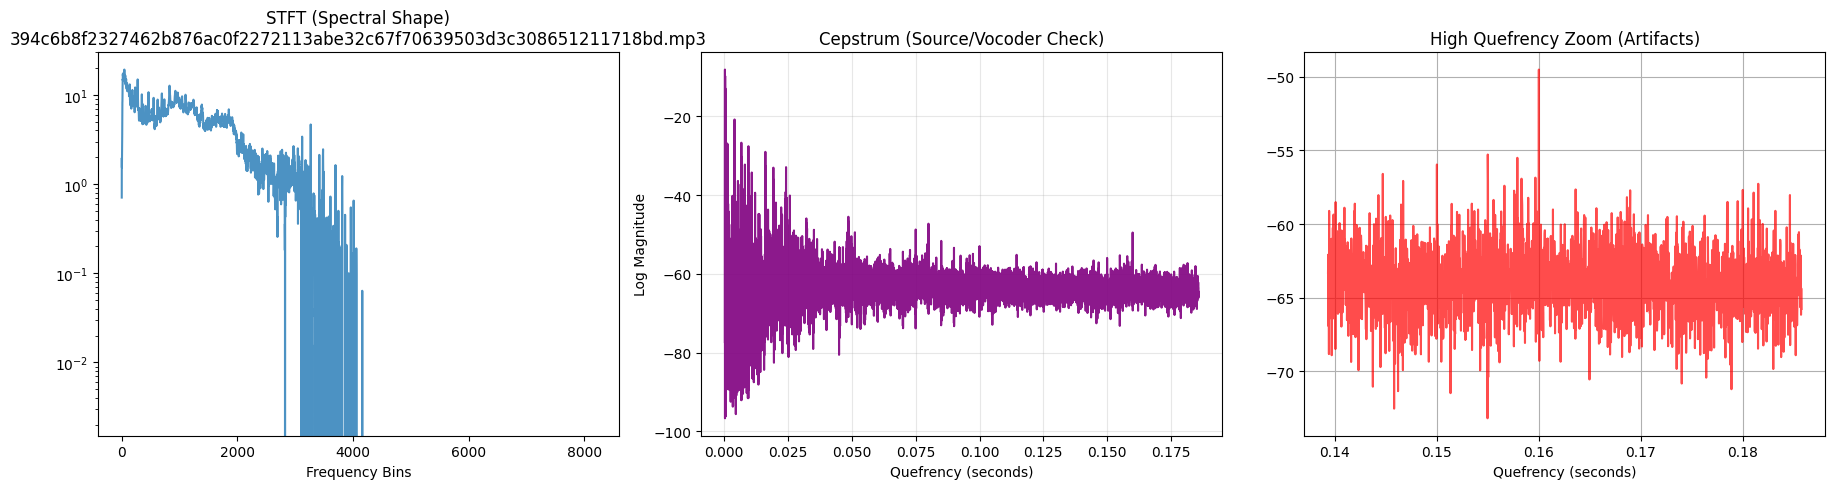

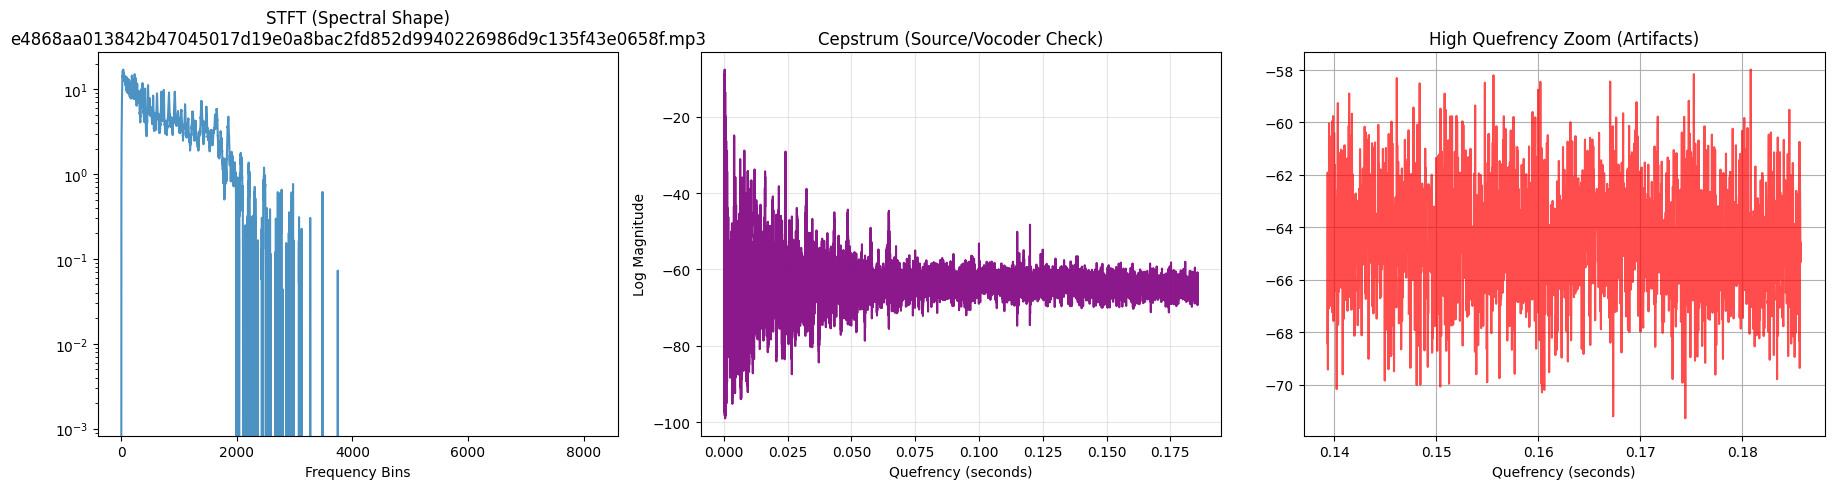

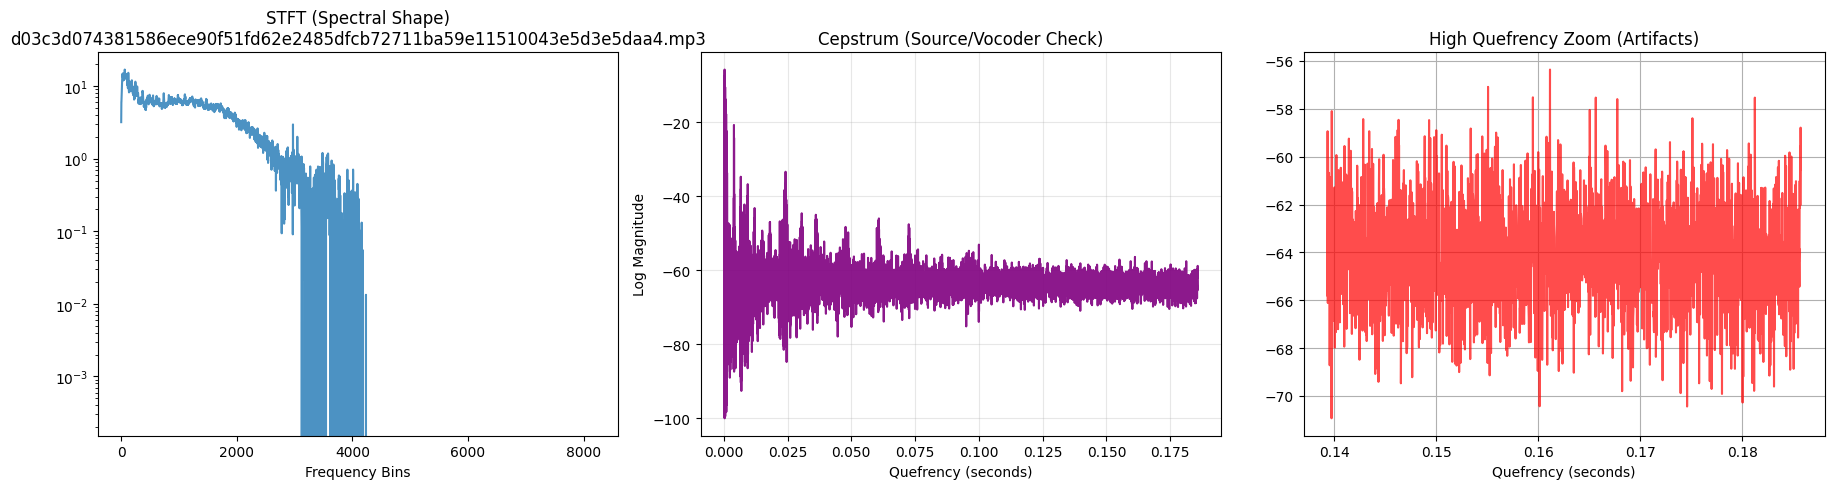

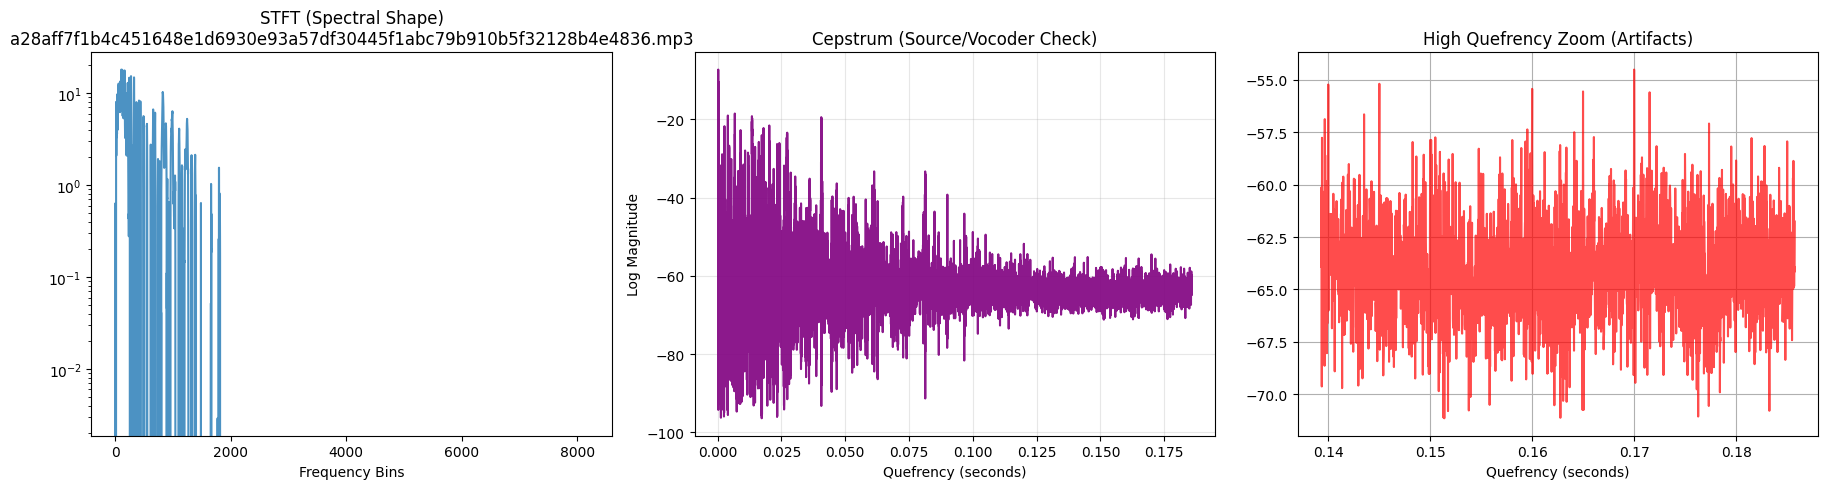

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Create the Quefrency Axis (in seconds)
# SR is likely 44100 or 24000 depending on Suno version
quefrency_axis = np.arange(cep_batch.shape[1]) / SR 

for i in range(len(audio_paths)):
    plt.figure(figsize=(18, 5))
    
    # 1. STFT (Frequency Domain)
    plt.subplot(1, 3, 1)
    plt.plot(stft_batch[i].cpu().numpy(), alpha=0.8)
    plt.title(f"STFT (Spectral Shape)\n{audio_paths[i].split('/')[-1]}")
    plt.xlabel("Frequency Bins")
    plt.yscale("log") # Log scale often helps see noise floor artifacts
    
    # 2. Cepstrum (Quefrency Domain)
    plt.subplot(1, 3, 2)
    # We skip bin 0 (DC) and maybe 1-5 (very slow changes) to see details
    start_bin = 10 
    plt.plot(quefrency_axis[start_bin:], cep_batch[i, start_bin:].cpu().numpy(), color='purple', alpha=0.9)
    plt.title("Cepstrum (Source/Vocoder Check)")
    plt.xlabel("Quefrency (seconds)")
    plt.ylabel("Log Magnitude")
    plt.grid(True, which="both", alpha=0.3)
    
    # 3. Zoomed in High-Quefrency (The "Fake Detector" Zone)
    plt.subplot(1, 3, 3)
    # Looking at the "tail" where vocoder artifacts usually live
    mid_point = 3* len(quefrency_axis) // 4
    plt.plot(quefrency_axis[mid_point:], cep_batch[i, mid_point:].cpu().numpy(), color='red', alpha=0.7)
    plt.title("High Quefrency Zoom (Artifacts)")
    plt.xlabel("Quefrency (seconds)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

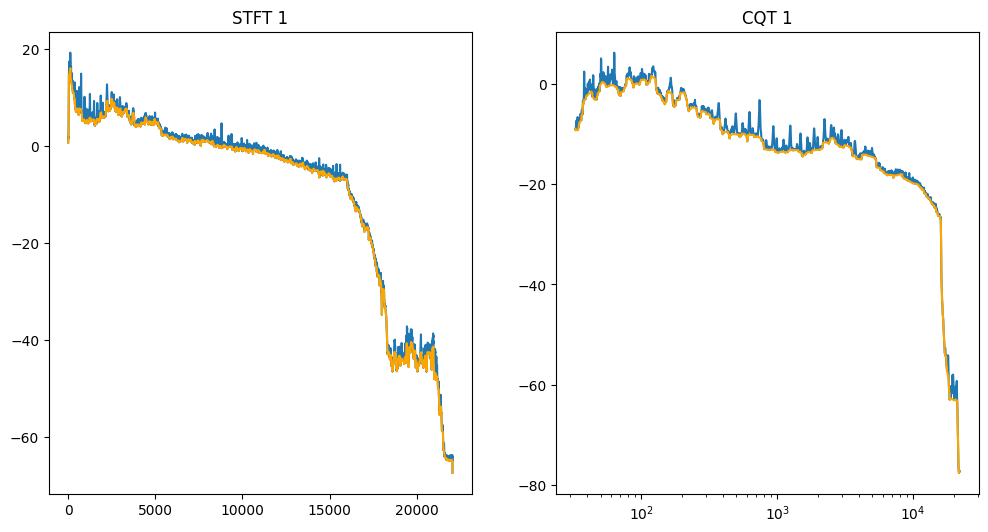

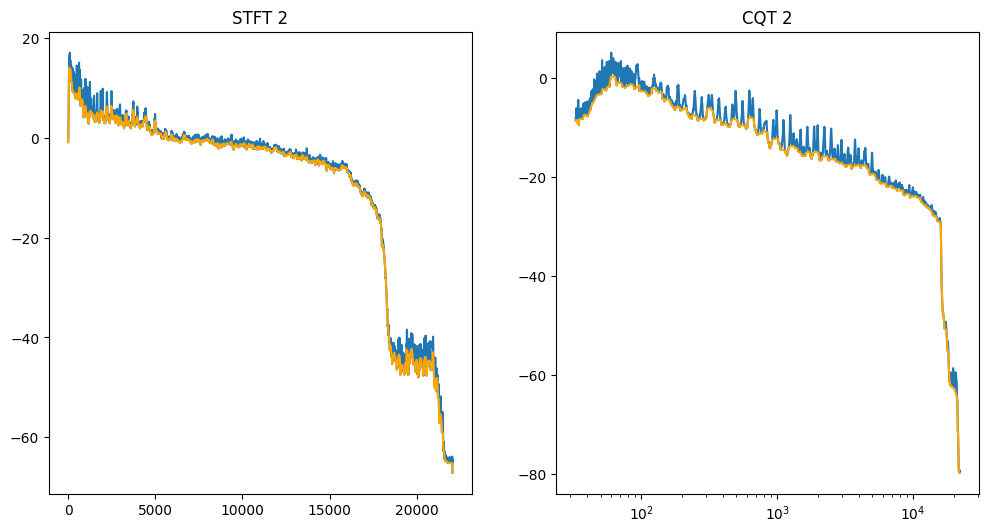

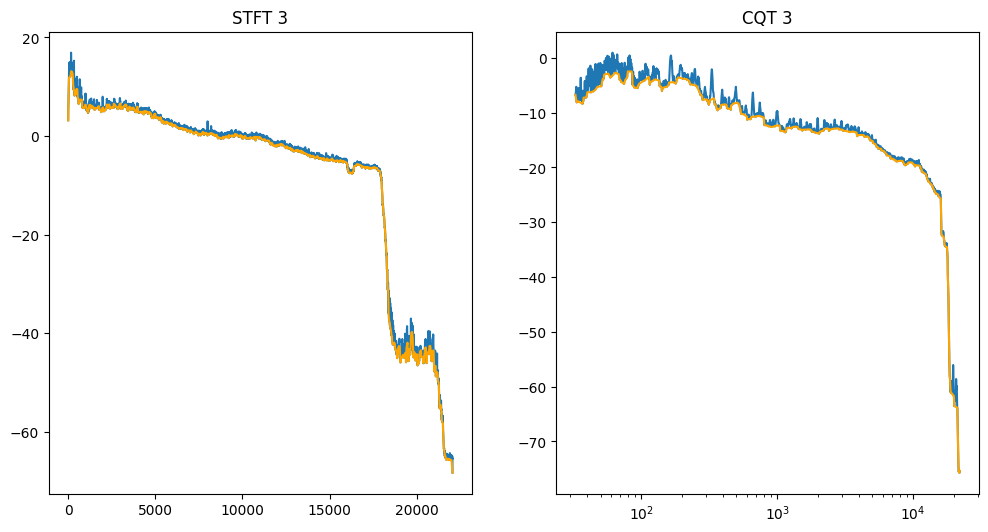

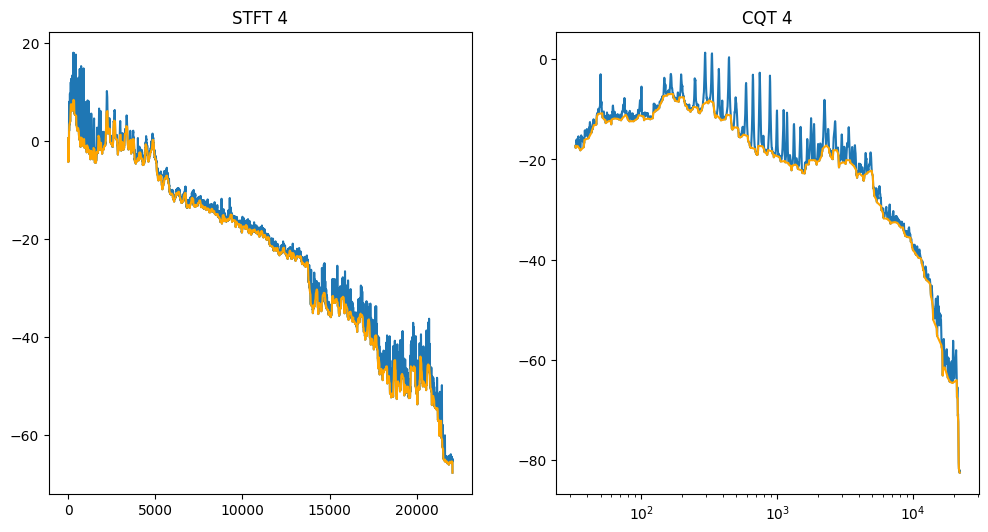

In [53]:
stft_low_hull_curve = get_low_hull_curve(stft_batch, area=AREA)
residue_stft = torch.clamp(stft_batch - stft_low_hull_curve, min=0)

cqt_low_hull_curve = get_low_hull_curve(cqt_batch, area=AREA)
residue_cqt = torch.clamp(cqt_batch - cqt_low_hull_curve, min=0)


for i in range(len(audio_paths)):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(freqs_crop.cpu().numpy(), stft_batch[i][mask].cpu().numpy())
    plt.plot(freqs_crop.cpu().numpy(), stft_low_hull_curve[i][mask].cpu().numpy(), label="Lower Hull", color="orange")
    plt.title(f"STFT {i+1}")

    plt.subplot(1, 2, 2)
    plt.plot(log_freqs_crop.cpu().numpy(), cqt_batch[i][log_mask].cpu().numpy())
    plt.plot(log_freqs_crop.cpu().numpy(), cqt_low_hull_curve[i][log_mask].cpu().numpy(), label="Lower Hull", color="orange")
    plt.title(f"CQT {i+1}")
    plt.xscale("log")

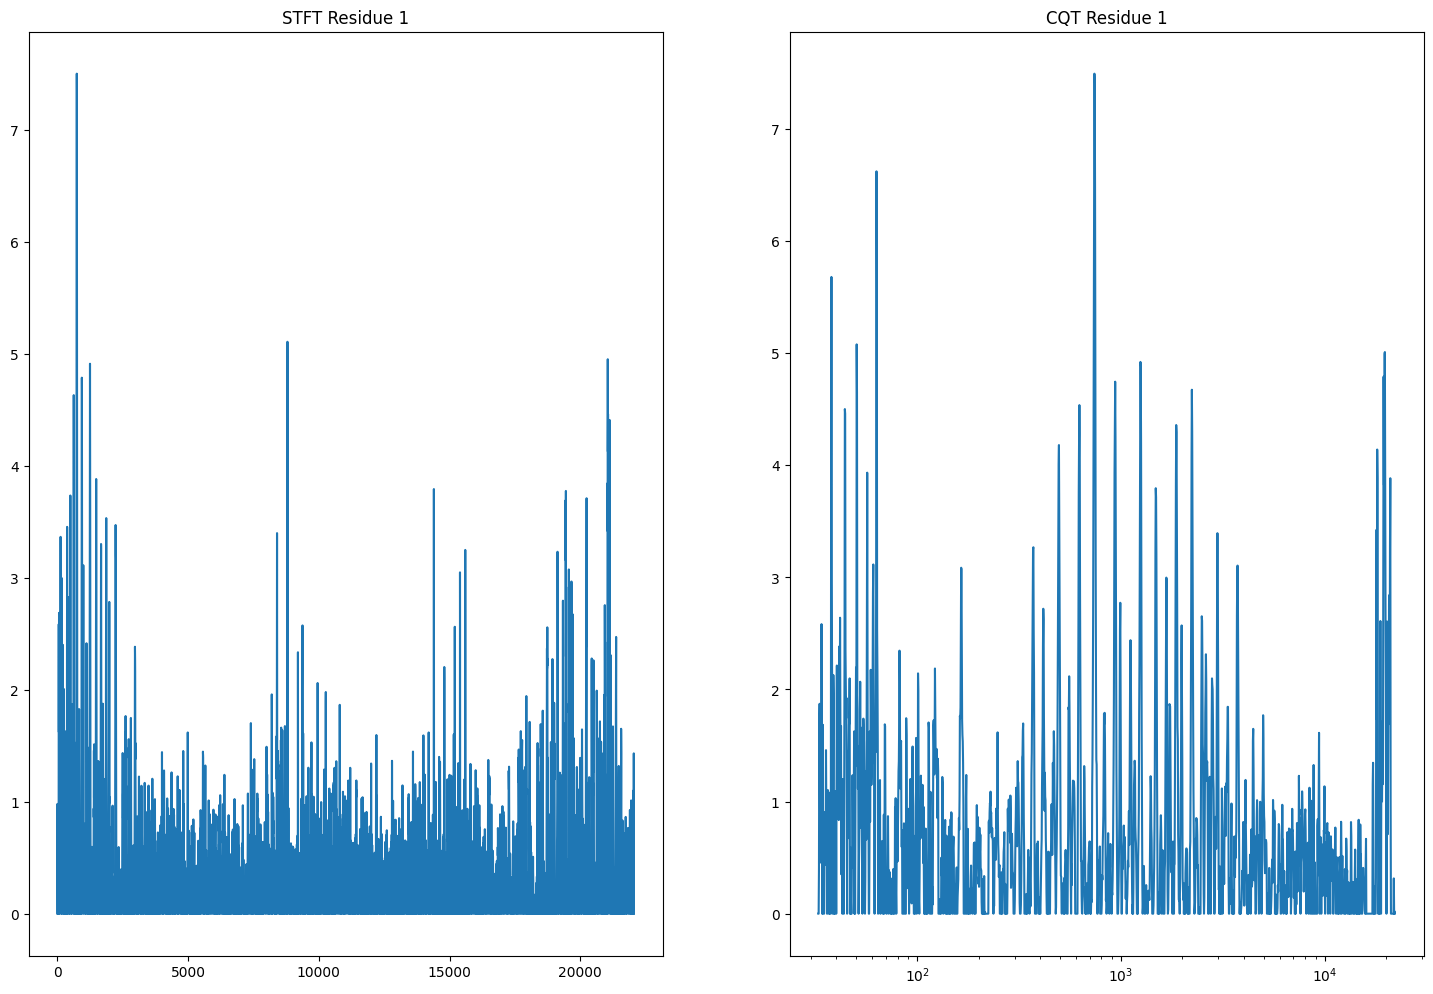

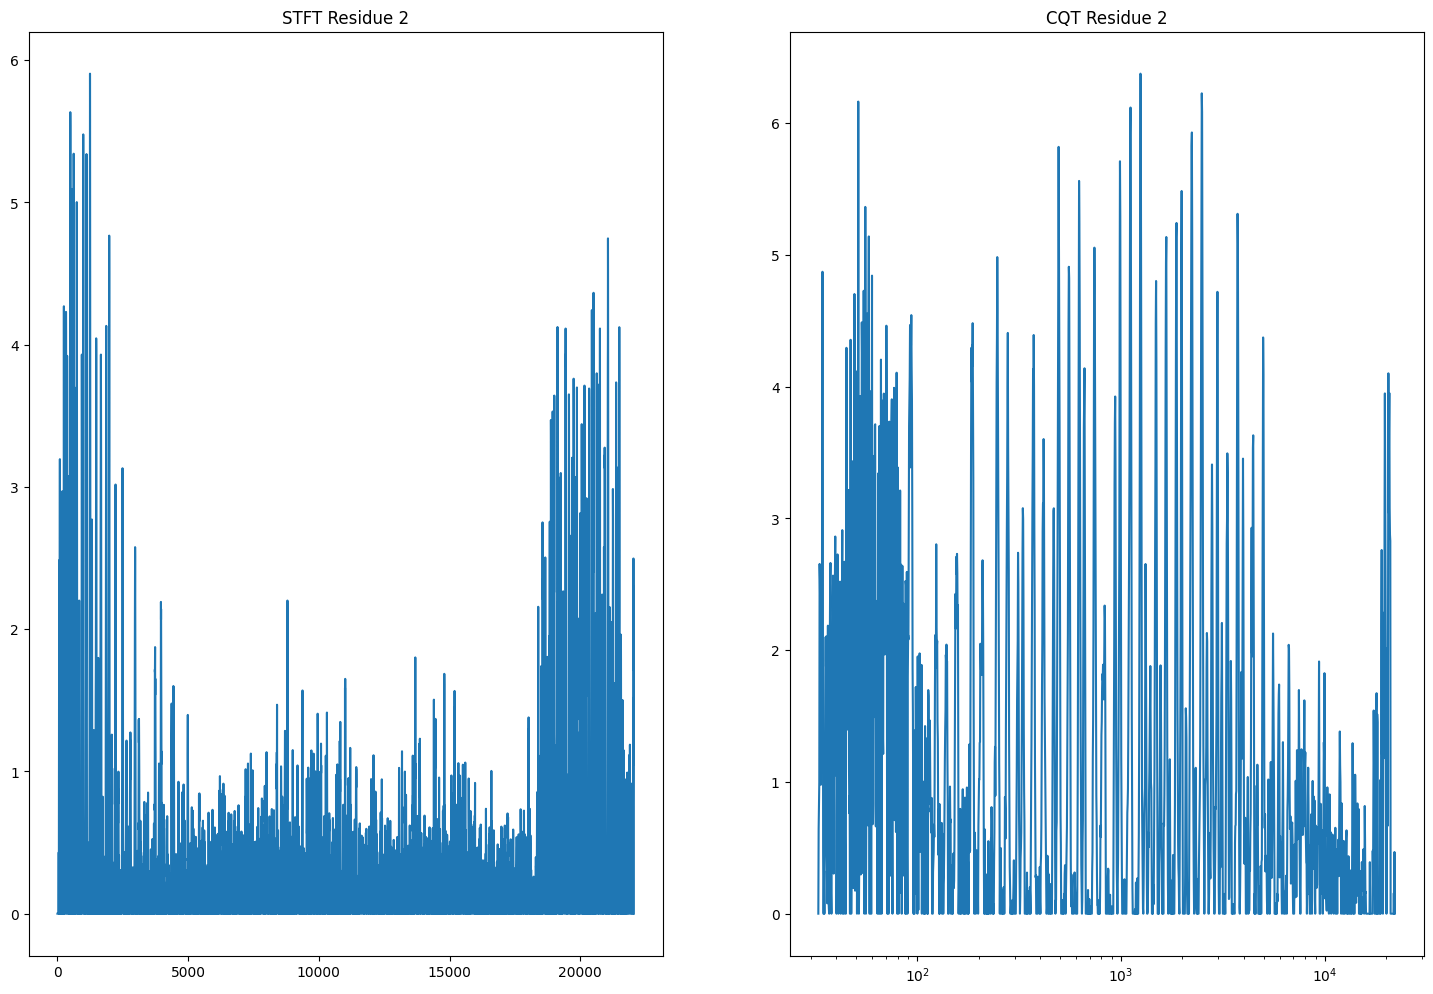

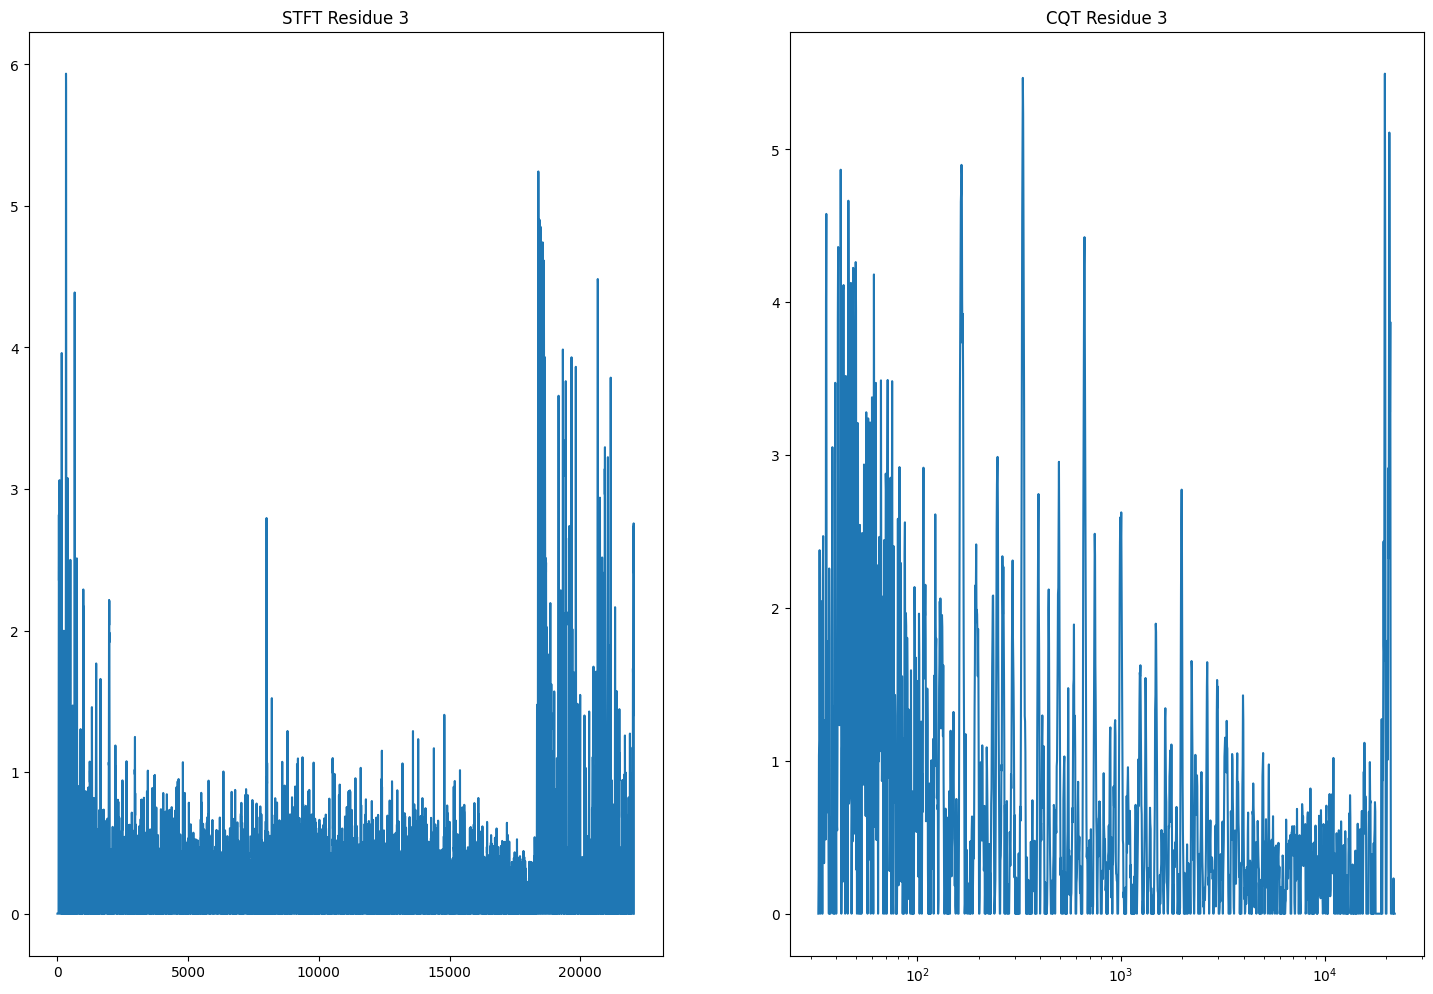

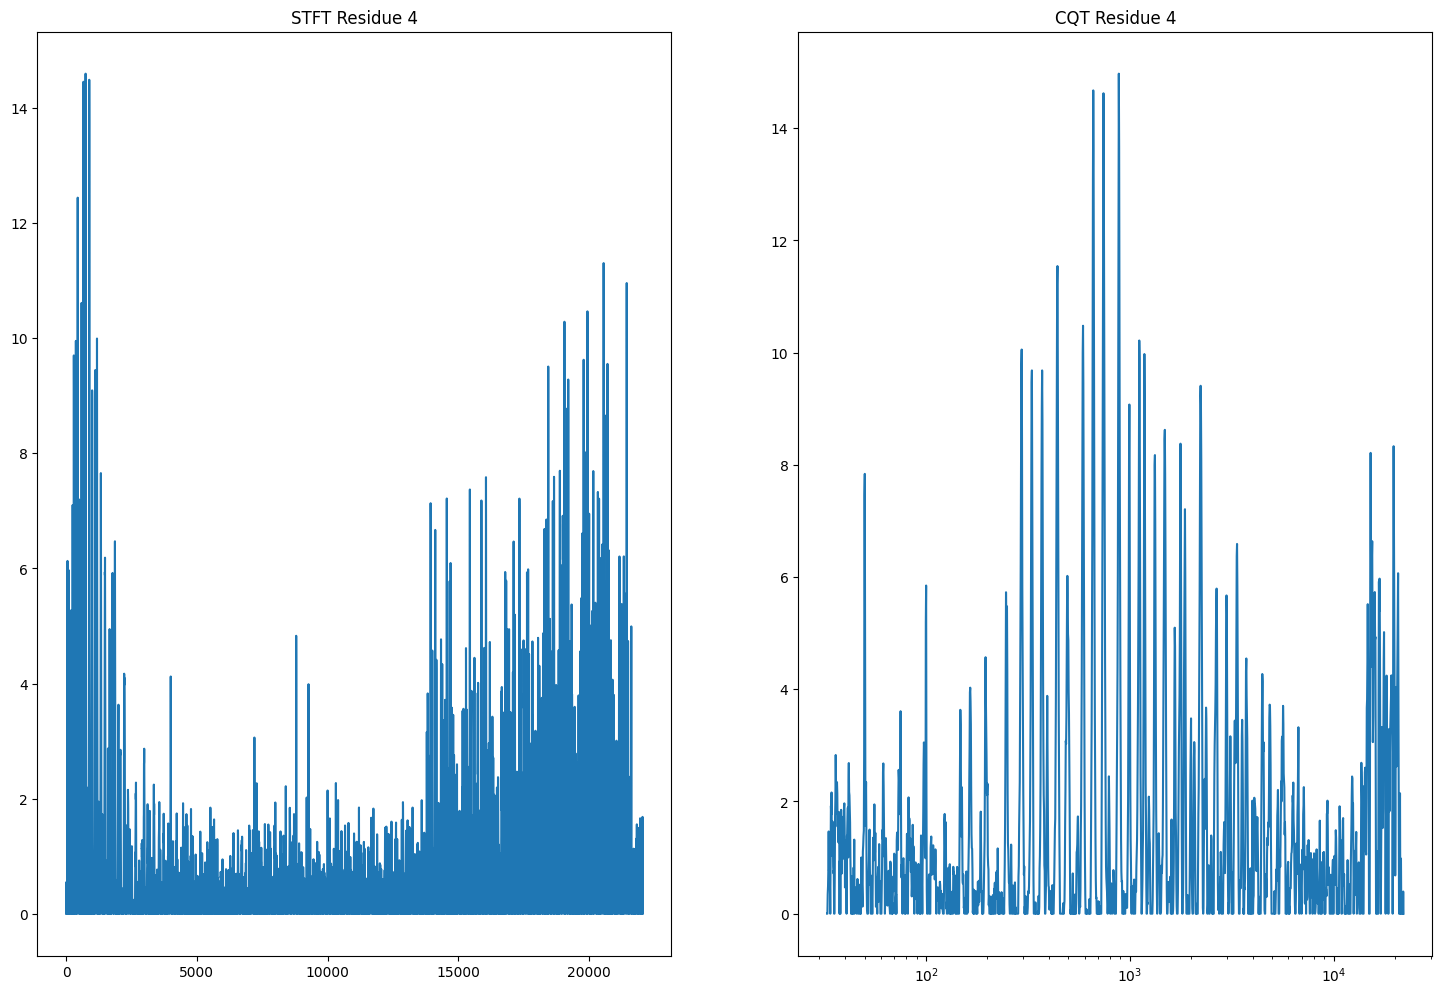

In [54]:
for i in range(len(audio_paths)):
    plt.figure(figsize=(18, 12))
    plt.subplot(1, 2, 1)
    plt.plot(freqs.cpu().numpy(), residue_stft[i].cpu().numpy())
    plt.title(f"STFT Residue {i+1}")
    
    plt.subplot(1, 2, 2)
    plt.plot(log_freqs.cpu().numpy(), residue_cqt[i].cpu().numpy())
    plt.title(f"CQT Residue {i+1}")
    plt.xscale("log")